# Problema propuesto – Regresión múltiple (Boston Housing)
## Tarea Computo II U20231085
### Marilyn Michelle Jiménez Arias

## 1. Descripción del conjunto de datos

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv("BostonHousing.csv")

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


**Interpretación:**

Este dataset tiene información sobre viviendas en Boston, todas sus variables son numéricas y no se observa que hay datos vacíos.
La variable más importante es **MEDV**, porque es la que queremos predecir (en este caso el precio de las casas).

## 2. División de datos y modelo

In [18]:
X = df.drop("medv", axis=1)
y = df["medv"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2026)


In [19]:
modelo_sklearn = LinearRegression()
modelo_sklearn.fit(X_train, y_train)

X_train_const = sm.add_constant(X_train)
modelo_ols = sm.OLS(y_train, X_train_const).fit()

print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     88.43
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          1.56e-107
Time:                        11:56:41   Log-Likelihood:                -1187.0
No. Observations:                 404   AIC:                             2402.
Df Residuals:                     390   BIC:                             2458.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.9950      5.567      6.645      0.0

**Interpretación:**

Se dividieron los datos en dos partes:  
- 80% para entrenar el modelo  
- 20% para probarlo  

Con esto se creó un modelo de regresión lineal múltiple para estimar el precio de las viviendas.

## 3. Variables no significativas

In [25]:
no_significativas = modelo_ols.pvalues[modelo_ols.pvalues > 0.05]
print(no_significativas)

crim     0.136960
indus    0.817802
chas     0.111445
age      0.779509
dtype: float64


**Interpretación:**

Las variables que tienen un **p-value mayor a 0.05** no influyen mucho en el modelo.  
Esas variables no ayudan a explicar el precio de las casas.

## 4. Multicolinealidad (VIF)

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X)

import pandas as pd

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i)
              for i in range(X_vif.shape[1])]

vif

,Variable,VIF
0,const,585.265238
1,crim,1.792192
2,zn,2.298758
3,indus,3.991596
4,chas,1.073995
5,nox,4.393720
6,rm,1.933744
7,age,3.100826
8,dis,3.955945
9,rad,7.484496


**Interpretación:**

El VIF nos dice si hay variables muy relacionadas entre sí.  
- Bajo → no hay problema  
- Alto → hay relación fuerte entre variables

## 5. Autovalores

In [22]:
import numpy as np

corr_matrix = X.corr()

eigenvalues, _ = np.linalg.eig(corr_matrix)

eigenvalues

array([6.12684883, 1.43327512, 1.24261667, 0.85757511, 0.83481594,
       0.65740718, 0.53535609, 0.39609731, 0.06350926, 0.27694333,
       0.16930298, 0.18601437, 0.22023782])

**Interpretación:**

Si hay valores cercanos a cero, puede haber multicolinealidad.

## Gráfico: valores reales vs predichos

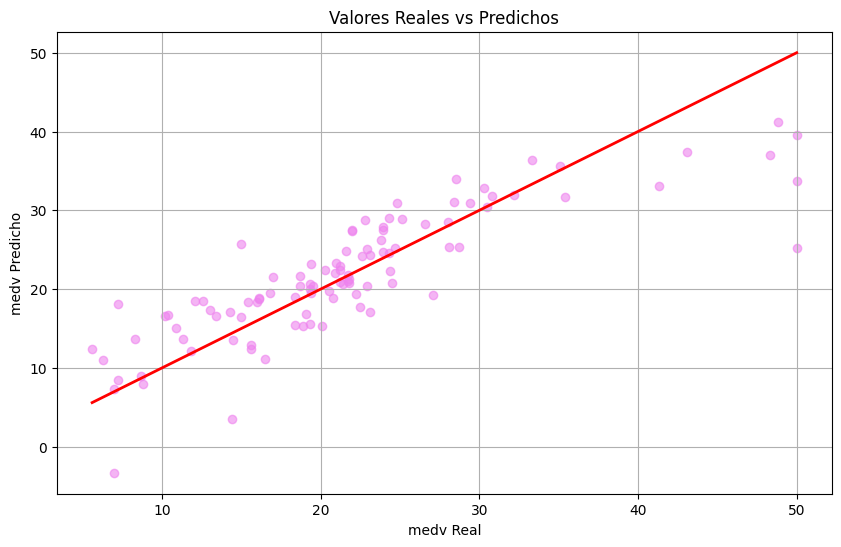

In [23]:
y_pred = modelo_sklearn.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='violet', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title('Valores Reales vs Predichos')
plt.xlabel('medv Real')
plt.ylabel('medv Predicho')
plt.grid(True)
plt.show()

**Interpretación:**

Si los puntos siguen una línea, el modelo funciona bien.

## 7. Predicción con medianas

In [24]:
medianas_variables = X.median().values.reshape(1, -1)
prediccion_final = modelo_sklearn.predict(pd.DataFrame(medianas_variables, columns=X.columns))

print(prediccion_final[0])

22.968776173765566


**Interpretación:**

Se obtiene el precio estimado de una vivienda promedio.

## Conclusión
Se creó un modelo para predecir el precio de las viviendas.  
Se analizaron las variables importantes y la relación entre ellas.  
El modelo permite hacer estimaciones razonables.